# Save the data in the right format

In [2]:
import numpy as np
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt
import random
import math

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from dataset import SuperResolutionDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import time

import torchmetrics
from skimage.metrics import structural_similarity as ssim

from tqdm import tqdm


import wandb



# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [4]:
train_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="train"
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 25, 25)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 125, 125)

test_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test"
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 25, 25)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 125, 125)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 25, 25])
HR Batch Shape: torch.Size([16, 1, 125, 125])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 25, 25])
HR Batch Shape: torch.Size([16, 1, 125, 125])


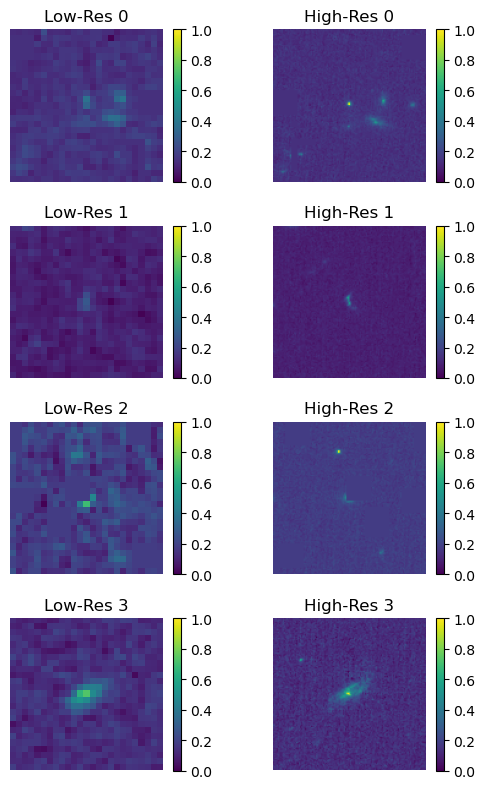

In [7]:
lr_hdf5_path = "../data/Nisp_train_cosmos.hdf5"
hr_hdf5_path = "../data/Nircam_train_cosmos.hdf5"

# === Load Training Dataset ===
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# === Fetch a batch from the training dataset ===
lr_batch, hr_batch = next(iter(train_loader))

# === Convert tensors to NumPy ===
lr_batch_np = lr_batch.squeeze(1).cpu().numpy()  
hr_batch_np = hr_batch.squeeze(1).cpu().numpy()  

# === Shared color scale ===
vmin = min(lr_batch_np.min(), hr_batch_np.min())
vmax = max(lr_batch_np.max(), hr_batch_np.max())

# === Plot first 4 samples ===
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig("superres_examples.png", dpi=300)  # Uncomment to save
plt.show()


# model

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from dataset import SuperResolutionDataset
import numpy as np
import math

# Set these at the beginning of your script
torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
torch.backends.cuda.matmul.allow_tf32 = True  # Allow TF32 for faster computation
torch.backends.cudnn.allow_tf32 = True

# Use channels_last memory format for better performance
def convert_to_channels_last(model):
    return model.to(memory_format=torch.channels_last)

class ResidualDenseBlock(nn.Module):
    """Enhanced Residual Dense Block with local feature fusion"""
    def __init__(self, channels, growth_rate=32):
        super(ResidualDenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_rate, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_rate, growth_rate, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2 * growth_rate, growth_rate, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3 * growth_rate, growth_rate, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4 * growth_rate, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x + x5  # Residual connection

class DetailEnhancementModule(nn.Module):
    """Advanced detail enhancement module"""
    def __init__(self, channels):
        super(DetailEnhancementModule, self).__init__()
        self.edge_conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, kernel_size=1)  # Changed to 1x1 conv
        )
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(1, channels//4), kernel_size=1),  # Ensure at least 1 channel
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(max(1, channels//4), channels, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Register edge detection kernel as buffer
        edge_kernel = torch.tensor([[-1, -1, -1], 
                                   [-1, 8, -1], 
                                   [-1, -1, -1]], dtype=torch.float32)
        self.register_buffer('edge_kernel', edge_kernel.reshape(1, 1, 3, 3))
        
    def forward(self, x):
        # Edge-aware feature extraction
        edge_kernel = self.edge_kernel.repeat(x.size(1), 1, 1, 1)
        edges = F.conv2d(x, edge_kernel, padding=1, groups=x.size(1))
        
        # Feature enhancement
        enhanced = self.edge_conv(x + edges)
        
        # Channel attention
        attention = self.attention(enhanced)
        
        return enhanced * attention

class EuclidToJWSTSuperResolution(nn.Module):
    def __init__(self, num_rrdb=8, features=64):  # Reduced from 16 to 8 blocks
        super(EuclidToJWSTSuperResolution, self).__init__()
        
        # Initial feature extraction
        self.conv_first = nn.Conv2d(1, features, kernel_size=3, padding=1)
        
        # Fewer but more efficient residual blocks
        self.rrdb_blocks = nn.ModuleList([ResidualDenseBlock(features, growth_rate=24) for _ in range(num_rrdb)])  # Reduced growth rate
        
        # Trunk convolution
        self.trunk_conv = nn.Conv2d(features, features, kernel_size=3, padding=1)
        
        # Simplified detail enhancement
        self.detail_enhancer = nn.Sequential(
            nn.Conv2d(features, features, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features, features, kernel_size=1)  # 1x1 conv is faster
        )
        
        # More efficient upsampling - direct to target size
        self.upsample = nn.Sequential(
            nn.Conv2d(features, features * 25, kernel_size=3, padding=1),  # 25 = 5x5 for 5x upsampling
            nn.PixelShuffle(5),  # Direct 5x upsampling (41*5 = 205)
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Final reconstruction
        self.final_conv = nn.Sequential(
            nn.Conv2d(features, features//2, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features//2, 1, kernel_size=1)
        )
        
    def forward(self, x):
        # Initial features
        features = self.conv_first(x)
        
        # Residual processing
        trunk = features
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        
        features = features + self.trunk_conv(trunk)
        
        # Detail enhancement
        features = self.detail_enhancer(features)
        
        # Direct upsampling to target size
        features = self.upsample(features)
        
        # Final output
        output = self.final_conv(features)
        
        return output

# SSIM Loss Implementation
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = self.create_window(window_size, self.channel)

    def gaussian(self, window_size, sigma):
        gauss = torch.Tensor([math.exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
        return gauss/gauss.sum()

    def create_window(self, window_size, channel):
        _1D_window = self.gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
        window = _2D_window.expand(channel, 1, window_size, window_size).contiguous()
        return window

    def _ssim(self, img1, img2, window, window_size, channel, size_average=True):
        mu1 = F.conv2d(img1, window, padding=window_size//2, groups=channel)
        mu2 = F.conv2d(img2, window, padding=window_size//2, groups=channel)

        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2

        sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=channel) - mu1_sq
        sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=channel) - mu2_sq
        sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=channel) - mu1_mu2

        C1 = 0.01**2
        C2 = 0.03**2

        ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2))/((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))

        if size_average:
            return ssim_map.mean()
        else:
            return ssim_map.mean(1).mean(1).mean(1)

    def forward(self, img1, img2):
        (_, channel, _, _) = img1.size()

        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = self.create_window(self.window_size, channel)
            
            if img1.is_cuda:
                window = window.cuda(img1.get_device())
            window = window.type_as(img1)
            
            self.window = window
            self.channel = channel

        return 1 - self._ssim(img1, img2, window, self.window_size, channel, self.size_average)

def train_two_stage(
    lr_hdf5_path,
    hr_hdf5_path,
    val_split=0.2,
    batch_size=8,
    num_epochs_stage1=50,
    num_epochs_stage2=50,
    use_amp=True,
    sample_fraction=1.0
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    scaler = GradScaler('cuda') if use_amp and device.type == 'cuda' else None

    full_dataset = SuperResolutionDataset(
        lr_hdf5_path=lr_hdf5_path,
        hr_hdf5_path=hr_hdf5_path,
        split='train',             # load the 'train' split from HDF5
        sample_fraction=sample_fraction,
        inference_mode=False
    )

    # train/val split
    torch.manual_seed(42)
    n = len(full_dataset)
    n_val = int(val_split * n)
    n_train = n - n_val
    train_ds, val_ds = random_split(full_dataset, [n_train, n_val])
    print(f"Dataset split: {n_train} train, {n_val} val samples")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2, shuffle=False,
                              num_workers=2, pin_memory=True, persistent_workers=True)

    # model setup
    model = EuclidToJWSTSuperResolution(num_rrdb=6, features=48).to(device)
    if hasattr(torch, 'compile'):
        model = torch.compile(model)
    model = convert_to_channels_last(model)

    # Stage-1
    print("\n=== Stage 1: Initial Training ===")
    opt1 = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched1 = torch.optim.lr_scheduler.OneCycleLR(opt1, max_lr=1e-3,
                                                 epochs=num_epochs_stage1,
                                                 steps_per_epoch=len(train_loader))
    l1 = nn.L1Loss()
    mse = nn.MSELoss()
    best1 = float('inf')

    for ep in range(num_epochs_stage1):
        model.train()
        running = 0.0
        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device, memory_format=torch.channels_last, non_blocking=True)
            hr_img = hr_img.to(device, memory_format=torch.channels_last, non_blocking=True)

            opt1.zero_grad()
            if scaler:
                with autocast():
                    out = model(lr_img)
                    loss = 0.7*l1(out, hr_img) + 0.3*mse(out, hr_img)
                scaler.scale(loss).backward()
                scaler.unscale_(opt1)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(opt1)
                scaler.update()
            else:
                out = model(lr_img)
                loss = 0.7*l1(out, hr_img) + 0.3*mse(out, hr_img)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                opt1.step()

            running += loss.item()
        sched1.step()

        # validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for lr_img, hr_img in val_loader:
                lr_img = lr_img.to(device)
                hr_img = hr_img.to(device)
                out = model(lr_img)
                val_loss += (0.7*l1(out, hr_img) + 0.3*mse(out, hr_img)).item()

        avg_train = running/len(train_loader)
        avg_val   = val_loss/len(val_loader)
        print(f"Stage1 Ep{ep+1}: train={avg_train:.4e}, val={avg_val:.4e}")
        if avg_val < best1:
            best1 = avg_val
            torch.save(model.state_dict(), 'stage1_best.pth')

    # Stage-2
    print("\n=== Stage 2: Fine-tuning ===")
    model.load_state_dict(torch.load('stage1_best.pth'))
    opt2 = torch.optim.Adam(model.parameters(), lr=5e-5)
    sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2,
                                                        T_max=num_epochs_stage2,
                                                        eta_min=1e-6)
    ssim = SSIMLoss()
    best2 = float('inf')

    for ep in range(num_epochs_stage2):
        model.train()
        running = 0.0
        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            opt2.zero_grad()
            out = model(lr_img)
            loss = 0.5*l1(out, hr_img) + 0.3*mse(out, hr_img) + 0.2*ssim(out, hr_img)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt2.step()
            running += loss.item()
        sched2.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for lr_img, hr_img in val_loader:
                lr_img = lr_img.to(device)
                hr_img = hr_img.to(device)
                out = model(lr_img)
                val_loss += (0.5*l1(out, hr_img)
                           + 0.3*mse(out, hr_img)
                           + 0.2*ssim(out, hr_img)).item()

        avg_train = running/len(train_loader)
        avg_val   = val_loss/len(val_loader)
        print(f"Stage2 Ep{ep+1}: train={avg_train:.4e}, val={avg_val:.4e}")
        if avg_val < best2:
            best2 = avg_val
            torch.save(model.state_dict(), 'final_best.pth')

    model.load_state_dict(torch.load('final_best.pth'))
    return model

model = EuclidToJWSTSuperResolution()
dummy_input = torch.randn(16, 1, 25, 25)
output = model(dummy_input)
print(output.shape)

torch.Size([16, 1, 125, 125])


# Train

In [45]:
from dataset import SuperResolutionDataset  # update if needed

# === Dataset & Loader ===
train_dataset = SuperResolutionDataset(
    lr_hdf5_path="../data/Nisp_train_cosmos.hdf5",
    hr_hdf5_path="../data/Nircam_train_cosmos.hdf5",
    split="train",
    sample_fraction=0.01
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
num_epochs=2
# === Train Loop ===
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()
    print(f"\n🚀 Starting Epoch {epoch+1}/{num_epochs}")

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):  # <== updated
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        outputs = model(lr_batch)
        loss = criterion(outputs, hr_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f} | Time: {time.time() - start_time:.2f}s")



🚀 Starting Epoch 1/2
✅ Epoch [1/2] Loss: 0.009337 | Time: 30.67s

🚀 Starting Epoch 2/2
✅ Epoch [2/2] Loss: 0.009360 | Time: 30.80s


In [20]:
model = train_two_stage(
        "../data/Nisp_train_cosmos.hdf5",
        "../data/Nircam_train_cosmos.hdf5",
        num_epochs_stage1=1,
        num_epochs_stage2=1,
        batch_size=2,
        use_amp=False,
        sample_fraction=0.01  # 👈 load just 1% of the data
    )


Using device: cpu
Dataset split: 340 train, 85 val samples

=== Stage 1: Initial Training ===
Stage1 Ep1: train=6.0947e-02, val=2.2824e-02

=== Stage 2: Fine-tuning ===
Stage2 Ep1: train=6.7835e-02, val=5.6221e-02


In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model has {count_parameters(model) / 1e6:.2f} million trainable parameters")


Model has 1.38 million trainable parameters


# Evaluate 

/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_86076/2280676274.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/opt/anaconda3/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


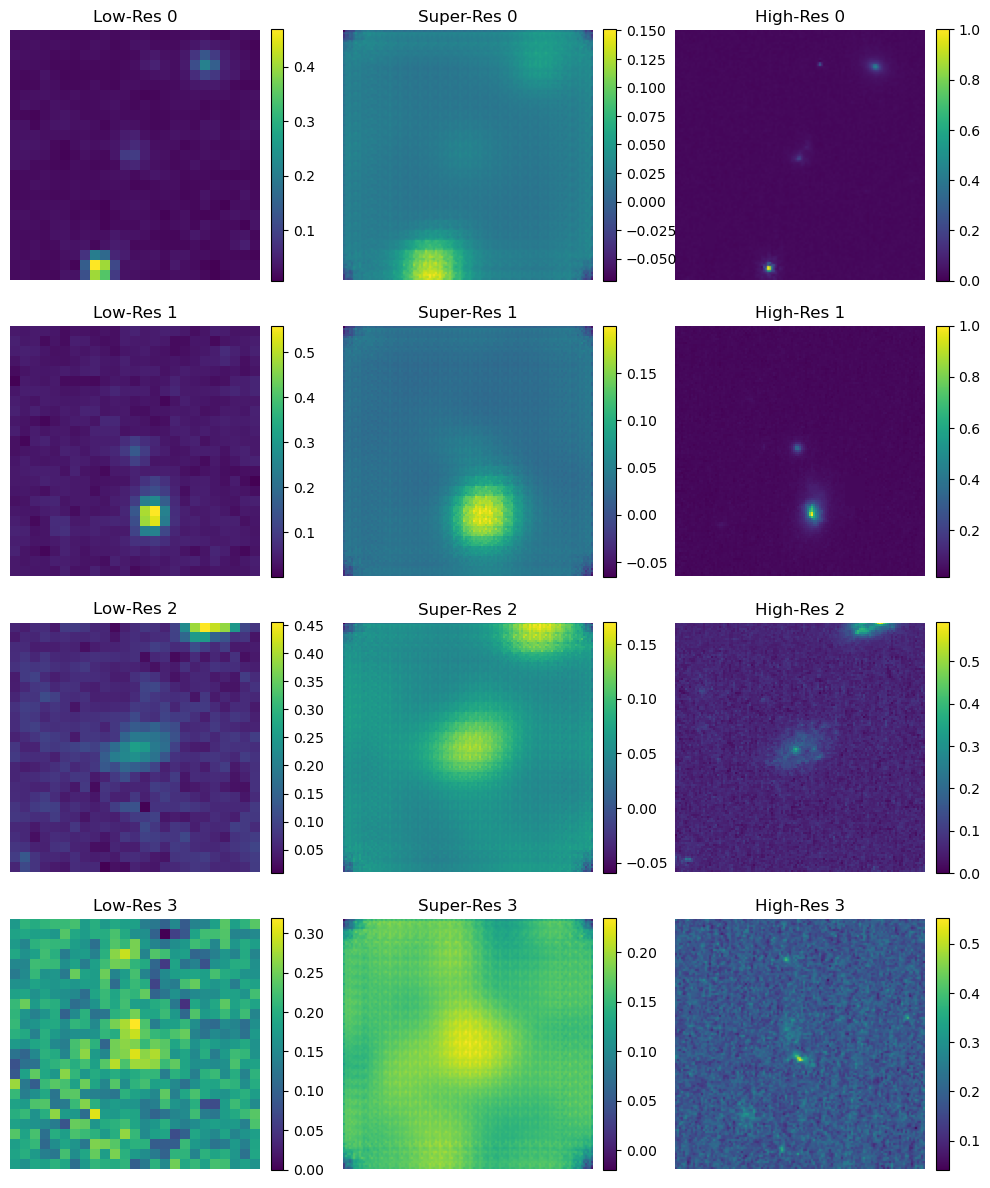

In [25]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random

# === Load trained model ===
#checkpoint_path = "super_resolution_model_test.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = EuclidToJWSTSuperResolution(num_rrdb=6, features=48).to(device)
#model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# === Define test loader ===
test_loader = DataLoader(
    SuperResolutionDataset(
        "../data/Nisp_train_cosmos.hdf5",
        "../data/Nircam_train_cosmos.hdf5",
        split="test",           # Assuming you have a "test" split in your HDF5 files
        sample_fraction=1.0
    ),
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# === Pick a random test batch ===
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# === Inference ===
with torch.no_grad(), torch.cuda.amp.autocast():
    sr_batch = model(lr_batch).cpu()

# === Convert to numpy for visualization ===
lr_batch_np = lr_batch.cpu().numpy()
sr_batch_np = sr_batch.numpy()
hr_batch_np = hr_batch.cpu().numpy()

# === Plot results ===
num_images = min(4, lr_batch_np.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Res
    img1 = axes[i, 0].imshow(lr_batch_np[i, 0], cmap='viridis')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved
    img2 = axes[i, 1].imshow(sr_batch_np[i, 0], cmap='viridis')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # Ground Truth
    img3 = axes[i, 2].imshow(hr_batch_np[i, 0], cmap='viridis')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
